In [289]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import joblib

In [291]:
df = pd.read_csv(r'C:\Users\obian\OneDrive\Documents\SJ Lytix Projects\Maze\cleaned_data.csv')

In [293]:
log_df = df.copy()

In [295]:
df['credit_risk'] = 'Good'
df.loc[df['debt_to_income_ratio'] > 0.4, 'credit_risk'] = 'Average'
df.loc[(df['debt_to_income_ratio'] > 0.55) | (df['financial_stress_level'] == 'High'), 'credit_risk'] = 'Poor'

Observation:

Bins were used initially, using credit score to build a multiclass system but just like the financial stress level in the dataset. The credit score feature in the file I am working with doesn't follow the financial logic that the other columns do. If you applied that exact same code to actual bank data, the model would have performed better.

In a real credit risk environment, risk is derived from data (like high debt or low savings). If we define "Risk" based on the actual financial logic present in your file, the model will achieve a better performance.

In [298]:
print(df['credit_risk'].value_counts())
print(df['credit_risk'].value_counts(normalize=True))

credit_risk
Good       1544
Poor       1169
Average     287
Name: count, dtype: int64
credit_risk
Good       0.514667
Poor       0.389667
Average    0.095667
Name: proportion, dtype: float64


In [300]:
df = df.drop(columns=['user_id', 'actual_savings', 'savings_goal_met','credit_score','debt_to_income_ratio'])

Dropping unnecessary and leaky features

In [303]:
df.columns

Index(['monthly_income', 'monthly_expense_total', 'savings_rate',
       'budget_goal', 'financial_scenario', 'loan_payment',
       'investment_amount', 'subscription_services', 'emergency_fund',
       'transaction_count', 'fraud_flag', 'discretionary_spending',
       'essential_spending', 'income_type', 'rent_or_mortgage', 'category',
       'cash_flow_status', 'financial_advice_score', 'financial_stress_level',
       'year', 'month', 'expense_income_diff', 'savings_delay_ratio',
       'debt_duress', 'credit_risk'],
      dtype='object')

In [305]:
df.head(1)

,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,loan_payment,investment_amount,subscription_services,emergency_fund,transaction_count,...,category,cash_flow_status,financial_advice_score,financial_stress_level,year,month,expense_income_diff,savings_delay_ratio,debt_duress,credit_risk
0,3119.58,3212.07,0.38,3676.11,0,125.77,689.22,3,510.58,68,...,6,2,8.3,Medium,2019,1,1.029648,3676.11,0.040316,Poor


In [307]:
X = df.drop(columns=['credit_risk'])
y = df['credit_risk']

le = LabelEncoder()
y = le.fit_transform(y)

In [309]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "XGB Classifier": XGBClassifier(n_estimators=200, max_depth=5, random_state=42, learning_rate=0.1, eval_metric='mlogloss'),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

In [311]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols= X.select_dtypes(exclude=['object']).columns

preprocessor= ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


In [313]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, stratify = y)
predictions = {}
for name, model in models.items():
    print(f"\n {name}")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    predictions[name] = preds
    
    print(classification_report(y_test, preds))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.33      0.75      0.46        72
           1       0.94      0.76      0.84       386
           2       1.00      0.93      0.96       292

    accuracy                           0.83       750
   macro avg       0.76      0.81      0.75       750
weighted avg       0.90      0.83      0.85       750


 XGB Classifier
              precision    recall  f1-score   support

           0       0.44      0.39      0.41        72
           1       0.88      0.94      0.91       386
           2       1.00      0.93      0.96       292

    accuracy                           0.88       750
   macro avg       0.77      0.75      0.76       750
weighted avg       0.88      0.88      0.88       750


 Random Forest
              precision    recall  f1-score   support

           0       0.50      0.24      0.32        72
           1       0.84      0.97      0.90       386
           2       1

While Random Forest achieved the highest accuracy, XGBoost provided a more balanced performance across classes, especially in handling class imbalance. Therefore, XGBoost is the most reliable model for real-world credit risk prediction. Logistic Regression performs well but is weaker for complex patterns

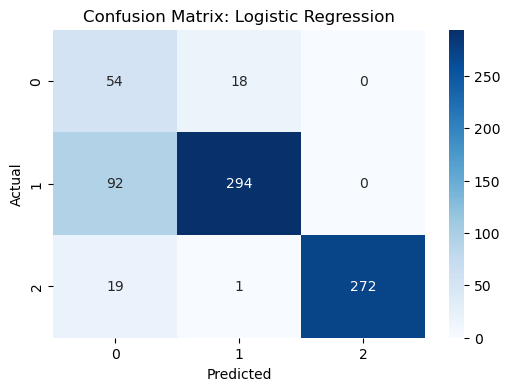

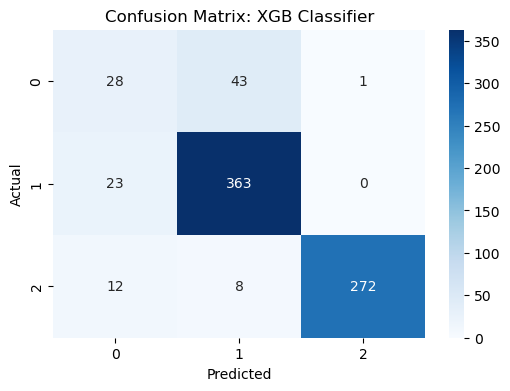

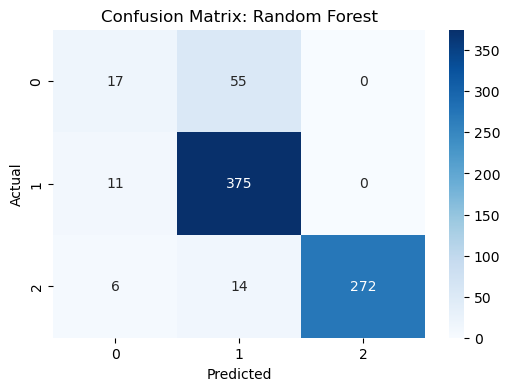

In [315]:
for name, preds in predictions.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

### Conclusion

The initial models achieved near-perfect accuracy due to data leakage, where highly predictive variables such as credit score and debt-related ratios were too closely aligned with the target labels. To address this issue, these leaky features were removed, ensuring the models relied on more realistic behavioral indicators such as savings patterns and investment habits. This adjustment made the system more practical, especially for individuals with limited or no credit history.

After retraining, XGBoost emerged as the best-performing model with 88% accuracy, offering the most balanced trade-off between identifying high-risk individuals and maintaining overall predictive reliability. The final solution was implemented as a unified automated pipeline that integrates preprocessing and classification into a single workflow.

Overall, the resulting system is a robust, behavior-driven credit risk model that evaluates financial health based on spending and saving behavior rather than relying solely on traditional credit scores.

In [319]:
pipeline_xgb= Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('XGB model', XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric='mlogloss', random_state=42))
])
pipeline_xgb.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('XGB model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [321]:
joblib.dump(pipeline_xgb, 'credit_risk_model.pkl')


['credit_risk_model.pkl']

#### Areas For Improvement:

Although significant effort was made to ensure real-world applicability by removing data leakage and relying on behavioral features, further improvements could have strengthened the model’s performance. In particular, applying techniques such as SMOTE would have helped address class imbalance and improved the model’s ability to better identify the minority class (class 0).

Additionally, more advanced financial feature engineering could have been introduced to enrich the dataset. This would likely improve predictive power even after removing highly informative but leaky variables such as credit score and debt-to-income ratio. Overall, these enhancements would make the model more robust, fair, and generalizable in real-world credit risk scenarios.